In [25]:
from scipy.stats import chi2_contingency, ks_2samp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [11]:
df = pd.read_parquet('./split_label_train_V3.snappy.parquet')

In [20]:

entity_profile_counts = df.groupby('entity_id')['profile_id'].nunique()
multi_entities = entity_profile_counts[entity_profile_counts > 1].index
single_entities = entity_profile_counts[entity_profile_counts == 1].index
multi_df = df[df['entity_id'].isin(multi_entities)]
df['is_multi_entity'] = df['entity_id'].isin(multi_entities)

In [8]:
#первый элемент - клиенты с одним профилем, второй - с несколькими
gmail_pair = [23111, 10996]
mailru_pair = [11826, 4889]
yandex_pair = [5145, 3309]
bk_pair = [1158, 450]
icloud_pair = [1133, 550]
other_pair = [1849, 925]
data = np.array([gmail_pair, mailru_pair, yandex_pair, bk_pair, icloud_pair, other_pair])
chi2, p, dof, expected = chi2_contingency(data)
print(f"X2: {chi2:.4f}")
print(f"p-value: {p:.4f}")
if(p < 0.05):
    print('Нулевая гипотеза отвергается. Есть статистически значимые различия в распределении по доменам у клиентов с одним и несколькими профилями')

X2: 267.2280
p-value: 0.0000
Нулевая гипотеза отвергается. Есть статистически значимые различия в распределении по доменам у клиентов с одним и несколькими профилями


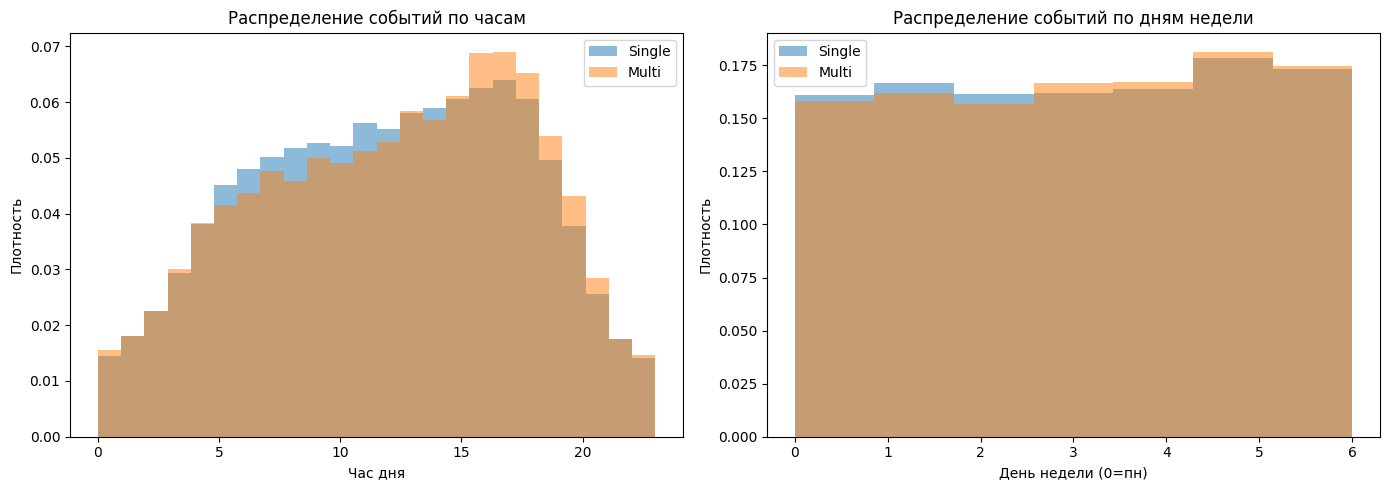


Временной разброс между первым и последним событием в multi entity (часы):
count    8073.000000
mean      863.364750
std      1000.672028
min         0.004244
10%         0.033138
25%         0.144520
50%       525.928405
75%      1446.304046
90%      2380.882521
95%      2895.168739
99%      3810.384530
max      4501.693754
dtype: float64

Профили созданы в течение 1 часа: 30.6%


C:\Users\RVN\AppData\Local\Temp\ipykernel_5580\725986806.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_spans = multi_df.groupby('entity_id').apply(get_time_span).dropna()


In [21]:
# Когда создаются профили (час дня)
df['hour'] = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# По часам
axes[0].hist(df[~df['is_multi_entity']]['hour'], bins=24, alpha=0.5, label='Single', density=True)
axes[0].hist(df[df['is_multi_entity']]['hour'], bins=24, alpha=0.5, label='Multi', density=True)
axes[0].set_xlabel('Час дня')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Распределение событий по часам')
axes[0].legend()

# По дням недели
axes[1].hist(df[~df['is_multi_entity']]['day_of_week'], bins=7, alpha=0.5, label='Single', density=True)
axes[1].hist(df[df['is_multi_entity']]['day_of_week'], bins=7, alpha=0.5, label='Multi', density=True)
axes[1].set_xlabel('День недели (0=пн)')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Распределение событий по дням недели')
axes[1].legend()

plt.tight_layout()
plt.show()

# Временная близость профилей в multi entity
def get_time_span(entity_group):
    times = entity_group['created_at']
    if len(times) < 2:
        return None
    return (times.max() - times.min()).total_seconds() / 3600  # в часах

time_spans = multi_df.groupby('entity_id').apply(get_time_span).dropna()

print(f"\nВременной разброс между первым и последним событием в multi entity (часы):")
print(time_spans.describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))

# Процент entity, где профили созданы в течение 1 часа
within_hour = (time_spans <= 1).mean()
print(f"\nПрофили созданы в течение 1 часа: {within_hour*100:.1f}%")

In [ ]:
# 1. Сравнение по часам дня (критерий хи‑квадрат)
print("\n1. СРАВНЕНИЕ ПО ЧАСАМ ДНЯ (критерий χ²):")

# Создаём таблицы частот
hours_single = df[~df['is_multi_entity']]['hour'].values
hours_multi = df[df['is_multi_entity']]['hour'].values

# Считаем частоты для каждого часа (0–23)
freq_single = Counter(hours_single)
freq_multi = Counter(hours_multi)

# Формируем таблицу сопряжённости 2×24
contingency_table_hours = []
for hour in range(24):
    contingency_table_hours.append([
        freq_single.get(hour, 0),  # частота в single
        freq_multi.get(hour, 0)   # частота в multi
    ])

contingency_table_hours = np.array(contingency_table_hours)

# Критерий хи‑квадрат
chi2_hours, p_hours, dof_hours, expected_hours = chi2_contingency(contingency_table_hours)

print(f"  χ² = {chi2_hours:.2f}")
print(f"  p‑value = {p_hours:.4e}")
print(f"  Степени свободы = {dof_hours}")

if p_hours < 0.05:
    print("  → Распределение по часам СТАТИСТИЧЕСКИ ЗНАЧИМО различается между single и multi")
else:
    print("  → Распределение по часам НЕ различается статистически значимо")

# 2. Сравнение по дням недели (критерий хи‑квадрат)
print("\n2. СРАВНЕНИЕ ПО ДНЯМ НЕДЕЛИ (критерий χ²):")

# Создаём таблицы частот
days_single = df[~df['is_multi_entity']]['day_of_week'].values
days_multi = df[df['is_multi_entity']]['day_of_week'].values

# Считаем частоты для каждого дня (0–6)
freq_single_days = Counter(days_single)
freq_multi_days = Counter(days_multi)

# Формируем таблицу сопряжённости 2×7
contingency_table_days = []
for day in range(7):
    contingency_table_days.append([
        freq_single_days.get(day, 0),
        freq_multi_days.get(day, 0)
    ])

contingency_table_days = np.array(contingency_table_days)

# Критерий хи‑квадрат
chi2_days, p_days, dof_days, expected_days = chi2_contingency(contingency_table_days)

print(f"  χ² = {chi2_days:.2f}")
print(f"  p‑value = {p_days:.4e}")
print(f"  Степени свободы = {dof_days}")

if p_days < 0.05:
    print("  → Распределение по дням недели СТАТИСТИЧЕСКИ ЗНАЧИМО различается между single и multi")
else:
    print("  → Распределение по дням недели НЕ различается статистически значимо")

# 3. Дополнительный тест: критерий Колмогорова‑Смирнова (непараметрический)
print("\n3. ДОПОЛНИТЕЛЬНЫЙ ТЕСТ: КРИТЕРИЙ КОЛМОГОРОВА‑СМИРНОВА")

ks_hours, ks_p_hours = ks_2samp(hours_single, hours_multi)
ks_days, ks_p_days = ks_2samp(days_single, days_multi)

print(f"  По часам: D = {ks_hours:.4f}, p‑value = {ks_p_hours:.4e}")
print(f"  По дням: D = {ks_days:.4f}, p‑value = {ks_p_days:.4e}")

if ks_p_hours < 0.05:
    print("  → KS‑тест подтверждает статистически значимые различия по часам")
else:
    print("  → KS‑тест не выявил значимых различий по часам")

if ks_p_days < 0.05:
    print("  → KS‑тест подтверждает статистически значимые различия по дням")
else:
    print("  → KS‑тест не выявил значимых различий по дням")


1. СРАВНЕНИЕ ПО ЧАСАМ ДНЯ (критерий χ²):
  χ² = 77.17
  p‑value = 9.0752e-08
  Степени свободы = 23
  → Распределение по часам СТАТИСТИЧЕСКИ ЗНАЧИМО различается между single и multi

2. СРАВНЕНИЕ ПО ДНЯМ НЕДЕЛИ (критерий χ²):
  χ² = 7.58
  p‑value = 2.7076e-01
  Степени свободы = 6
  → Распределение по дням недели НЕ различается статистически значимо

3. ДОПОЛНИТЕЛЬНЫЙ ТЕСТ: КРИТЕРИЙ КОЛМОГОРОВА‑СМИРНОВА
(не требует категоризации, работает с исходными данными)
  По часам: D = 0.0283, p‑value = 6.4829e-11
  По дням: D = 0.0106, p‑value = 6.5905e-02
  → KS‑тест подтверждает статистически значимые различия по часам
  → KS‑тест не выявил значимых различий по дням
